In [1]:
import pandas as pd

# Load the dataset
data = pd.read_pickle('../../data/processed/cleaned_articles.pkl')

In [2]:
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39863 entries, 0 to 39862
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              39863 non-null  object
 1   publisher          39863 non-null  object
 2   date               39863 non-null  object
 3   section            39863 non-null  object
 4   body               39863 non-null  object
 5   length             39863 non-null  int64 
 6   letters_flag       39863 non-null  bool  
 7   country_flag       39863 non-null  object
 8   foreign_countries  39863 non-null  object
 9   us_mentions        39863 non-null  object
 10  source_file        39863 non-null  object
 11  publisher_raw      39863 non-null  object
 12  section_clean      39845 non-null  object
 13  section_category   34176 non-null  object
dtypes: bool(1), int64(1), object(12)
memory usage: 4.0+ MB


,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,"[Brazil, Lima (Capital)]","[New York, US, United States]",NYT/1.DOCX,The New York Times,world; americas,World/International
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters


In [3]:
print(data.columns)


Index(['title', 'publisher', 'date', 'section', 'body', 'length',
       'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions',
       'source_file', 'publisher_raw', 'section_clean', 'section_category'],
      dtype='object')


### Preprocess with custom stopwords

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ---- 1. Define custom stopwords ----
custom_stopwords = {
    'said', 'say', 'saying', 'told',
    'mr', 'ms', 'mrs',
    'report', 'reported', 'interview', 'according',
    'article', 'photo', 'photograph', 'graphic',
    'someone', 'anyone', 'everyone', 'everybody',
    'york', 'new', 'time','much', 'many', 'way', 'often', 'even', 'always', 'got', 'get', 'never', 'among','could',
    'would','last','also','still','whether','opinion','times','photos','photographs','number','year','month','day',
    'week','decade','know','thing','went','far','recent','lately', 'th','around','page','near','section facebook',
    'follow section','twitter nytopinion','nytopinion','facebook twitter','back','like','make','made','see','author'

}

# ---- 2. Merge with NLTK stopwords ----
stop_words = set(stopwords.words('english')).union(custom_stopwords)

# ---- 3. Lemmatizer ----
lemmatizer = WordNetLemmatizer()

# ---- 4. Preprocess function ----
def preprocess(text):
    text = text.lower()  
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep letters, spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)

# ---- 5. Apply cleaning ----
data['clean_text'] = data['title'].astype(str).apply(preprocess)

data[['title', 'clean_text']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jingguo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/jingguo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,title,clean_text
0,A Well-Documented Childhood. A Very Private Life.,well documented childhood private life
1,These were the big stories in arts and culture...,big story art culture dayton region
2,She Exalted The Beauty Of Dance,exalted beauty dance
3,"Under a Highway in Rio, a Dance Style Charms a...",highway rio dance style charm generation brazi...
4,"Congressional pay, minimum wage stagnant for y...",congressional pay minimum wage stagnant year o...


### Vectorize (CountVectorizer)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=50000,     # Limit vocabulary size for efficiency
    ngram_range=(1, 2)      # include unigrams + bigramslike "small business" and "self employment"

)

# Vectorize the clean_text column
X = vectorizer.fit_transform(data['clean_text'])

# Extract vocabulary
vocab = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocab))
vocab[:30]   # Show the first 30 vocabulary items


Vocabulary size: 50000


array(['aaa', 'aaron', 'abandon', 'abandoned', 'abatement', 'abbey',
       'abbie', 'abbott', 'abbott district', 'abbotts', 'abc',
       'abc cancel', 'abc comedy', 'abc plan', 'abdication', 'abducted',
       'abduction', 'abe', 'abel', 'abidjan', 'abidjan journal',
       'ability', 'able', 'able fewer', 'aboard', 'abolish',
       'abolish police', 'abolitionist', 'abortion', 'abortion clinic'],
      dtype=object)

### Define anchors + build anchor_indices + missing_anchors

In [6]:
# Step 3: Define anchor words 
anchor_words_dict = {
    'Housing': [
        'housing', 'rent', 'tenant', 'affordable', 'homelessness',
        'landlord', 'eviction', 'apartment', 'mortgage'
    ],
    'Education': [
        'education', 'school', 'college', 'teacher', 'university', 'tuition',
        'student', 'curriculum', 'classroom', 'learning'
    ],
    'Union': [
        'union', 'labor', 'strike', 'worker', 'collective',
        'organizing', 'wage', 'bargaining', 'employment'
    ],
    'Election': [
        'election', 'vote', 'campaign', 'party', 'candidate', 'rally',
        'politics', 'ballot', 'primary', 'poll', 'democrat', 'republican'
    ],
    'Military': [
        'military', 'service', 'veteran', 'army', 'soldier',
        'defense', 'troop', 'combat', 'deployment', 'navy','ptsd','active duty','civilian life','war'
    ],
    'Indebtedness': [
        'debt', 'indebtedness','struggle', 'credit', 'bankrupt', 'bankruptcy',
        'loan', 'foreclosure', 'repayment', 'interest', 'borrower', 'default', 'financial'
    ],
    'Family': [
        'family', 'child', 'parent', 'marriage', 'spouse', 'household',
        'domestic', 'raising', 'sibling', 'divorce', 'wedding', 'extended family', 'kin'  # bigram
    ],
    'Art': [
        'art', 'review', 'theater', 'play', 'movie',
        'culture', 'film', 'gallery', 'music', 'performance', 'exhibition', 'artist'
    ],
    'Health': [
        'overdose', 'health','patient', 'disease', 'treatment', 'mental', 'therapy',
        'nurse', 'clinic', 'pandemic', 'loneliness', 'medicine', 'doctor','addiction','insurance','drug'
    ],
    'Business Ownership': [
        'business', 'entrepreneur', 'self employment','business owner','self employed',   
        'client', 'customer', 'firm', 'owner', 'small business'   # bigram
    ],
    'Sports': [
        'soccer', 'hockey', 'athlete', 'league', 'tournament', 'game', 'score','sport'
    ],
    'Religion': [
        'faith', 'islamic', 'sermon', 'worship', 'belief','religion', 'church', 'temple', 'mosque', 'christianity', 'catholic',
        'evangelical'
    ],
    'Crime': [
        'police', 'policeman', 'crime', 'theft', 'criminal','gunshot', 'homicide'
    ],
     'Books': [
        'book','author','novel','book review', 'write', 'wrote','poem','poetry','fiction','non fiction'
    ]
    
}

topic_names = list(anchor_words_dict.keys())

# Map words to vocabulary indices
word_to_idx = {w: i for i, w in enumerate(vocab)}

anchor_indices = []
for topic, words in anchor_words_dict.items():
    idx_list = [word_to_idx[w] for w in words if w in word_to_idx]
    anchor_indices.append(idx_list)
    print(f"{topic}: {len(idx_list)} anchors found out of {len(words)} total")


Housing: 9 anchors found out of 9 total
Education: 10 anchors found out of 10 total
Union: 9 anchors found out of 9 total
Election: 12 anchors found out of 12 total
Military: 10 anchors found out of 14 total
Indebtedness: 11 anchors found out of 13 total
Family: 12 anchors found out of 13 total
Art: 12 anchors found out of 12 total
Health: 15 anchors found out of 16 total
Business Ownership: 8 anchors found out of 10 total
Sports: 8 anchors found out of 8 total
Religion: 11 anchors found out of 12 total
Crime: 6 anchors found out of 7 total
Books: 9 anchors found out of 10 total


In [7]:
# Inspect which anchor words are missing from the vocabulary
missing_anchors = {}

for topic, words in anchor_words_dict.items():
    missing = [w for w in words if w not in word_to_idx]
    if missing:
        missing_anchors[topic] = missing

missing_anchors


{'Military': ['deployment', 'ptsd', 'active duty', 'civilian life'],
 'Indebtedness': ['indebtedness', 'repayment'],
 'Family': ['extended family'],
 'Health': ['overdose'],
 'Business Ownership': ['self employment', 'self employed'],
 'Religion': ['christianity'],
 'Crime': ['gunshot'],
 'Books': ['non fiction']}

### Train corex2 (strength=3) + print topic

In [8]:
from corextopic import corextopic as ct

corex5 = ct.Corex(
    n_hidden=len(topic_names),
    seed=42
)

corex5.fit(
    X,
    words=vocab,
    anchors=anchor_indices,
    anchor_strength=3 ### change stregnth here
)

print("Total correlation (TC):", corex5.tc)


Total correlation (TC): 6.529807624883852


In [9]:
n_words = 15  

for i, topic in enumerate(corex5.get_topics(n_words=n_words)):
    print(f"\n### Topic {i+1}: {topic_names[i]}")
    for word, score, idx in topic:
        print(f"{word:20} {score:.3f}")



### Topic 1: Housing
housing              0.114
affordable           0.032
rent                 0.024
apartment            0.016
tenant               0.013
landlord             0.012
mortgage             0.010
affordable housing   0.006
angeles              0.005
los angeles          0.005
los                  0.005
eviction             0.005
wall street          0.004
homelessness         0.004
cortez               0.004

### Topic 2: Education
school               0.189
student              0.096
college              0.075
education            0.035
teacher              0.024
university           0.017
tuition              0.015
learning             0.013
tax                  0.010
plan                 0.008
high school          0.005
tax plan             0.004
classroom            0.004
high                 0.004
income               0.004

### Topic 3: Union
worker               0.107
union                0.101
labor                0.091
strike               0.053
wage            

In [10]:
print(topic_names)

['Housing', 'Education', 'Union', 'Election', 'Military', 'Indebtedness', 'Family', 'Art', 'Health', 'Business Ownership', 'Sports', 'Religion', 'Crime', 'Books']


In [11]:
import pandas as pd

# ---------------------------------------------------
# 1. Put topic names here
# ---------------------------------------------------
topic_names = [ # why creating a new list here? what's the difference?
    "Housing",
    "Education",
    "Union",
    "Election",
    "Military",
    "Indebtedness",
    "Family",
    "Art",
    "Health",
    "Business Ownership",
    "Sports",
    "Religion",
    "Crime",
    "Books"
]

# ---------------------------------------------------
# 2. Convert Corex output to readable string
# ---------------------------------------------------
def topic_to_string(topic):
    return "; ".join([f"{w} ({score:.3f})" for w, score, idx in topic])

# ---------------------------------------------------
# 3. Build table for FINAL model 
# ---------------------------------------------------
n_words = 15
topics_out = corex5.get_topics(n_words=n_words)

rows = []
for i, name in enumerate(topic_names):
    row = {
        "Topic": name,
        "Anchor words": ", ".join(anchor_words_dict[name]),
        "Top words (anchor_strength=5)": topic_to_string(topics_out[i]),
    }
    rows.append(row)

df = pd.DataFrame(rows)

# ---------------------------------------------------
# 4. Save as Excel
# ---------------------------------------------------
output_path = "corex_topics_anchor5.xlsx"
df.to_excel(output_path, index=False)

output_path


'corex_topics_anchor5.xlsx'

In [12]:
import numpy as np

# ---------------------------------------------------
# Topic-level TC extraction (robust across versions)
# ---------------------------------------------------
def get_topic_level_tc(corex_model):
    """
    Return a 1D numpy array of per-topic TC (length = n_hidden),
    if available in the fitted CorEx model.
    """
    # Common attribute names seen across implementations
    candidate_attrs = [
        "tcs",          # often per-topic TC
        "tc",           # sometimes vector, sometimes scalar overall TC
        "topic_tc",     # possible custom name
        "tc_per_topic", # possible custom name
    ]

    for attr in candidate_attrs:
        if hasattr(corex_model, attr):
            val = getattr(corex_model, attr)
            if val is None:
                continue
            arr = np.asarray(val)
            # We want a vector, not a scalar
            if arr.ndim == 1 and arr.size > 1:
                return arr.astype(float)

    # Common method name patterns
    candidate_methods = [
        "get_tcs",
        "get_tc",
        "get_topic_tcs",
        "get_topic_tc",
        "get_tc_per_topic",
    ]
    for m in candidate_methods:
        if hasattr(corex_model, m) and callable(getattr(corex_model, m)):
            val = getattr(corex_model, m)()
            if val is None:
                continue
            arr = np.asarray(val)
            if arr.ndim == 1 and arr.size > 1:
                return arr.astype(float)

    raise AttributeError(
        "Could not find per-topic TC in the model object. "
        "Please print(dir(corex5)) and share the output; we can locate the right field."
    )

# ---------------------------------------------------
# Print topic-level TC aligned to topic_names
# ---------------------------------------------------
topic_tcs = get_topic_level_tc(corex5)

print("Overall TC (corex5.tc):", getattr(corex5, "tc", None))
print("Topic-level TC vector length:", len(topic_tcs))
print()

# Safety check: topic_names should match n_hidden
if len(topic_names) != len(topic_tcs):
    print(f"WARNING: len(topic_names)={len(topic_names)} != len(topic_tcs)={len(topic_tcs)}")
    print("I will still print by index up to the smaller length.\n")

n = min(len(topic_names), len(topic_tcs))
for i in range(n):
    print(f"{i:02d}\t{topic_names[i]}\t{topic_tcs[i]:.6f}")

# If want to see ranking (optional):
print("\n--- Ranked by Topic-level TC (desc) ---")
rank_idx = np.argsort(-topic_tcs)
for r, i in enumerate(rank_idx[:n], start=1):
    name = topic_names[i] if i < len(topic_names) else f"Topic_{i}"
    print(f"{r:02d}\t{i:02d}\t{name}\t{topic_tcs[i]:.6f}")

Overall TC (corex5.tc): 6.529807624883852
Topic-level TC vector length: 14

00	Housing	0.435931
01	Education	0.507901
02	Union	0.462838
03	Election	1.061518
04	Military	0.434397
05	Indebtedness	0.332893
06	Family	0.417525
07	Art	0.755947
08	Health	0.416135
09	Business Ownership	0.353603
10	Sports	0.359894
11	Religion	0.326397
12	Crime	0.259441
13	Books	0.405388

--- Ranked by Topic-level TC (desc) ---
01	03	Election	1.061518
02	07	Art	0.755947
03	01	Education	0.507901
04	02	Union	0.462838
05	00	Housing	0.435931
06	04	Military	0.434397
07	06	Family	0.417525
08	08	Health	0.416135
09	13	Books	0.405388
10	10	Sports	0.359894
11	09	Business Ownership	0.353603
12	05	Indebtedness	0.332893
13	11	Religion	0.326397
14	12	Crime	0.259441


In [12]:
topic_scores = corex5.transform(X)


In [13]:

topic_scores.shape



(39863, 14)

In [16]:
corr_matrix = pd.DataFrame(
    np.corrcoef(topic_scores.T),
    index=topic_names,
    columns=topic_names
)

corr_matrix


,Housing,Education,Union,Election,Military,Indebtedness,Family,Art,Health,Business Ownership,Sports,Religion,Crime,Books
Housing,1.000000,-0.018339,-0.023344,-0.024573,-0.027407,-0.009345,-0.020551,-0.030783,-0.017343,-0.014668,-0.013700,-0.018525,0.000984,-0.044465
Education,-0.018339,1.000000,-0.011305,-0.029464,-0.025343,0.012437,-0.003354,-0.043434,-0.015699,0.005373,-0.019380,-0.007127,-0.003479,-0.030088
Union,-0.023344,-0.011305,1.000000,0.044752,-0.015922,-0.006933,-0.016178,-0.042677,-0.019775,-0.017397,-0.022434,-0.026638,-0.016312,-0.016661
Election,-0.024573,-0.029464,0.044752,1.000000,0.022677,0.023496,-0.023351,-0.107619,-0.029009,0.003163,-0.019542,-0.037277,-0.035552,0.000165
Military,-0.027407,-0.025343,-0.015922,0.022677,1.000000,0.000709,-0.017506,-0.023479,-0.016265,-0.024041,-0.016853,-0.026290,0.017062,-0.024500
Indebtedness,-0.009345,0.012437,-0.006933,0.023496,0.000709,1.000000,0.010362,-0.030628,-0.015289,0.003838,-0.009606,-0.024322,-0.024512,-0.012146
Family,-0.020551,-0.003354,-0.016178,-0.023351,-0.017506,0.010362,1.000000,-0.013966,-0.010501,-0.014405,-0.018395,-0.002133,0.004430,-0.023833
Art,-0.030783,-0.043434,-0.042677,-0.107619,-0.023479,-0.030628,-0.013966,1.000000,-0.010800,-0.026161,-0.016620,-0.015919,-0.039757,0.008184
Health,-0.017343,-0.015699,-0.019775,-0.029009,-0.016265,-0.015289,-0.010501,-0.010800,1.000000,-0.008238,-0.025194,-0.023313,-0.014070,-0.023151
Business Ownership,-0.014668,0.005373,-0.017397,0.003163,-0.024041,0.003838,-0.014405,-0.026161,-0.008238,1.000000,-0.009091,-0.012091,-0.015488,-0.030020


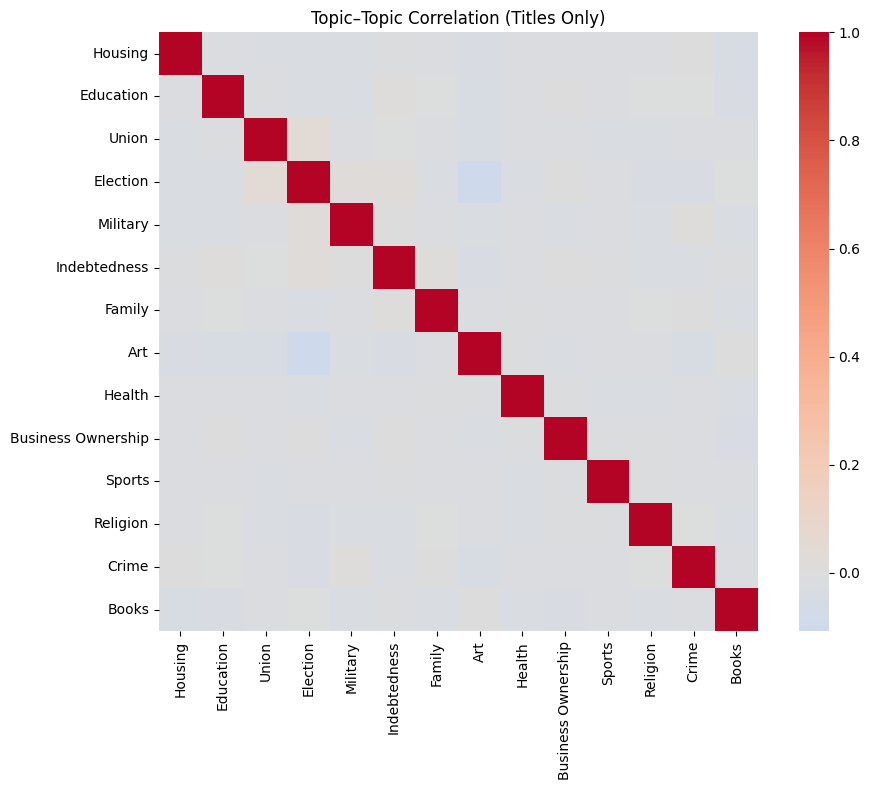

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Topic–Topic Correlation (Titles Only)')
plt.tight_layout()
plt.show()


In [20]:
threshold = 0.8  # change threashold here
n_labels = (topic_scores > threshold).sum(axis=1)

print("Mean #topics per article:", n_labels.mean())
print("Median:", np.median(n_labels))
print("Pct >= 3 topics:", (n_labels >= 3).mean())

Mean #topics per article: 0.9508065123046434
Median: 1.0
Pct >= 3 topics: 0.03878283119684921


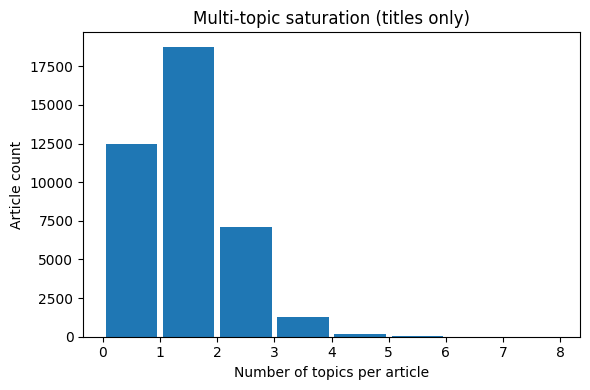

In [21]:
plt.figure(figsize=(6,4))
plt.hist(n_labels, bins=range(n_labels.max()+2), rwidth=0.9)
plt.xlabel('Number of topics per article')
plt.ylabel('Article count')
plt.title('Multi-topic saturation (titles only)')
plt.tight_layout()
plt.show()


##### Labeling


In [18]:
import os
import re
import numpy as np
import pandas as pd

# -------------------------
# Params
# -------------------------
THRESHOLD = 0.8
TOP_K = 3
TOP_N_PER_TOPIC = 10

# Repo root 
REPO_ROOT = "../../"
OUT_ROOT = os.path.join(REPO_ROOT, "example_articles", "CorEx")

# -------------------------
# Ensure date/year fields
# -------------------------
df = data.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

# -------------------------
# Publisher group (NYT vs Other)
# -------------------------
df["publisher_group"] = np.where(
    df["publisher"].astype(str).str.contains("New York Times", case=False, na=False),
    "NYT",
    "Other"
)

# -------------------------
# Topic scores matrix
# -------------------------
topic_scores = corex5.p_y_given_x
assert topic_scores.shape[0] == len(df), "topic_scores rows must match df rows"
assert topic_scores.shape[1] == len(topic_names), "topic_scores cols must match topic_names length"


In [19]:
# -------------------------
# Step 1. Labeling: threshold + topK cap
# -------------------------
topic_scores = np.asarray(topic_scores)

# topK indices per doc (descending)
topk_idx = np.argpartition(-topic_scores, kth=TOP_K-1, axis=1)[:, :TOP_K]
topk_scores = np.take_along_axis(topic_scores, topk_idx, axis=1)

# sort the topK internally by score desc
order = np.argsort(-topk_scores, axis=1)
topk_idx = np.take_along_axis(topk_idx, order, axis=1)
topk_scores = np.take_along_axis(topk_scores, order, axis=1)

# apply threshold
mask = topk_scores > THRESHOLD

# build labels + label_scores columns
labels_list = []
label_scores_list = []

for i in range(len(df)):
    idxs = topk_idx[i][mask[i]]
    scs  = topk_scores[i][mask[i]]
    labs = [topic_names[j] for j in idxs]
    labels_list.append(labs)
    label_scores_list.append([float(x) for x in scs])

df["labels"] = labels_list
df["label_scores"] = label_scores_list
df["n_labels"] = df["labels"].apply(len)

# quick sanity check
summary = {
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "pct_with_>=1_label": float((df["n_labels"] >= 1).mean()),
    "pct_with_>=2_labels": float((df["n_labels"] >= 2).mean()),
    "pct_with_>=3_labels": float((df["n_labels"] >= 3).mean()),
    "avg_labels_per_doc": float(df["n_labels"].mean()),
    "max_labels_any_doc": int(df["n_labels"].max()),
}
summary


{'threshold': 0.8,
 'top_k': 3,
 'pct_with_>=1_label': 0.6873792740134962,
 'pct_with_>=2_labels': 0.2168176002809623,
 'pct_with_>=3_labels': 0.03878283119684921,
 'avg_labels_per_doc': 0.9429797054913077,
 'max_labels_any_doc': 3}

In [19]:
df.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category,clean_text,year,publisher_group,labels,label_scores,n_labels
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National,well documented childhood private life,2024,NYT,[],[],0
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None,big story art culture dayton region,2024,Other,"[Art, Business Ownership]","[0.999999, 0.999999]",2
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture,exalted beauty dance,2024,NYT,[],[],0
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,"[Brazil, Lima (Capital)]","[New York, US, United States]",NYT/1.DOCX,The New York Times,world; americas,World/International,highway rio dance style charm generation brazi...,2024,NYT,[],[],0
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters,congressional pay minimum wage stagnant year o...,2024,Other,"[Housing, Union]","[0.999999, 0.999999]",2


In [20]:
# -------------------------
# Step 2. Build a long table of (doc, topic) pairs that passed labeling
# -------------------------
topic_to_idx = {t:i for i,t in enumerate(topic_names)}
print("topic_to_idx: ", topic_to_idx)

rows = []
for doc_i in range(len(df)):
    labs = df.at[doc_i, "labels"]
    #print("labs: ", labs)
    if not labs:
        continue
    for t in labs:
        ti = topic_to_idx[t]
        rows.append({
            "doc_index": doc_i,
            "topic": t,
            "topic_score": float(topic_scores[doc_i, ti]),
            "publisher_group": df.at[doc_i, "publisher_group"],
        })

pairs_df = pd.DataFrame(rows)

# top N per topic per publisher_group
top_df = (
    pairs_df
    .sort_values(["publisher_group", "topic", "topic_score"], ascending=[True, True, False])
    .groupby(["publisher_group", "topic"], as_index=False)
    .head(TOP_N_PER_TOPIC)
)

top_df.head()


topic_to_idx:  {'Housing': 0, 'Education': 1, 'Union': 2, 'Election': 3, 'Military': 4, 'Indebtedness': 5, 'Family': 6, 'Art': 7, 'Health': 8, 'Business Ownership': 9, 'Sports': 10, 'Religion': 11, 'Crime': 12, 'Books': 13}


,doc_index,topic,topic_score,publisher_group
7,11,Art,0.999999,NYT
61,52,Art,0.999999,NYT
101,87,Art,0.999999,NYT
124,106,Art,0.999999,NYT
151,131,Art,0.999999,NYT


In [21]:
# -------------------------
# Step 3. Export full-body txt files
# -------------------------
def safe_filename(s: str, max_len: int = 120) -> str:
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"[^A-Za-z0-9._\- ]+", "", s)   # keep it simple & cross-platform
    s = s.replace(" ", "_")
    return (s[:max_len] if len(s) > max_len else s) or "untitled"

os.makedirs(OUT_ROOT, exist_ok=True)

def write_one_txt(doc_row, topic, topic_score, out_dir):
    title = doc_row.get("title", "")
    publisher = doc_row.get("publisher", "")
    date = doc_row.get("date", "")
    section = doc_row.get("section", "")
    source_file = doc_row.get("source_file", "")
    body = doc_row.get("body", "")
    labels = doc_row.get("labels", "")
    label_scores = doc_row.get("label_scores", "")

    header = [
        f"TITLE: {title}",
        f"TOPIC: {topic}",
        f"SCORE: {topic_score:.6f}",
        f"PUBLISHER: {publisher}",
        f"DATE: {date}",
        f"SECTION: {section}",
        f"SOURCE_FILE: {source_file}",
        f"LABEL: {labels}",
        f"LABEL SCORES: {label_scores}",
        "",
        "BODY:",
        "",
    ]
    content = "\n".join(header) + str(body)

    fname = safe_filename(f"{topic}__{date}__{title}") + ".txt"
    path = os.path.join(out_dir, fname)

    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

# folder structure: example_articles/CorEx/{NYT|Other}/{Topic}/
n_written = 0
for _, r in top_df.iterrows():
    doc_i = int(r["doc_index"])
    topic = r["topic"]
    topic_score = float(r["topic_score"])
    pub_g = r["publisher_group"]

    out_dir = os.path.join(OUT_ROOT, pub_g, topic)
    os.makedirs(out_dir, exist_ok=True)

    write_one_txt(df.iloc[doc_i], topic, topic_score, out_dir) # to do: check this
    n_written += 1

n_written


280

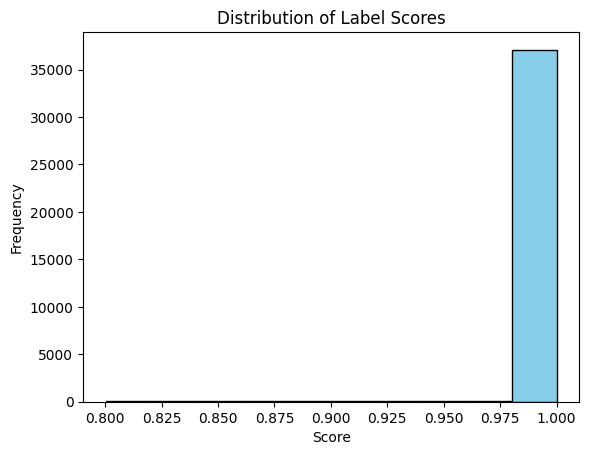

In [22]:
import matplotlib.pyplot as plt
flattened_list = [item for sublist in list(df['label_scores']) for item in sublist]
plt.hist(flattened_list, bins=10, color='skyblue', edgecolor='black') # 'bins' parameter controls the number of bars
plt.title('Distribution of Label Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# to do: get all topics with scores from original df

In [18]:
import subprocess

def sh(cmd, cwd=REPO_ROOT):
    print(">>>", cmd)
    return subprocess.run(cmd, cwd=cwd, shell=True, check=True, text=True)

sh("git status")
sh("git add example_articles/CorEx")
sh('git commit -m "Add CorEx example articles (top10 per topic, threshold 0.8, topK 3)"')
sh("git push")


>>> git status
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   analysis/2.topic_analaysis/Corex_Guided Topic Modeling.ipynb
	modified:   analysis/2.topic_analaysis/corex_topics_anchor5.xlsx
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-11_000000__Paris_Hilton_and_Nicole_Richie_Revisit_The_Simple_Life.txt
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-12_000000__Green_Acres_To_New_Pastures.txt
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-14_000000__Dubai.txt
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-14_000000__Saving_Englands_Music_Oasis_From_a_New_Wave_of_Development.txt
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-16_000000__A_Success_Story_Of_Frazzled_Charm_And_Endless_Yalls.txt
	modified:   example_articles/CorEx/NYT/Art/Art__2024-12-25

>>> git commit -m "Add CorEx example articles (top10 per topic, threshold 0.8, topK 3)"
[main 169aad72] Add CorEx example articles (top10 per topic, threshold 0.8, topK 3)
 280 files changed, 4223 insertions(+), 261 deletions(-)
 create mode 100644 example_articles/CorEx/NYT/Business Ownership/Business_Ownership__2024-11-05_000000__Fifth_Avenue_The_Street_of_Dreams_for_Over_a_Century.txt
 create mode 100644 example_articles/CorEx/NYT/Business Ownership/Business_Ownership__2024-11-05_000000__Tiny_Homes_Face_the_Ax_in_Hong_Kong_Leaving_Many_Families_Worried.txt
 create mode 100644 example_articles/CorEx/NYT/Business Ownership/Business_Ownership__2024-12-13_000000__As_East_Villages_Little_India_Fades_One_Place_Keeps_Its_Lights_On.txt
 create mode 100644 example_articles/CorEx/NYT/Business Ownership/Business_Ownership__2024-12-14_000000__Dubai.txt
 create mode 100644 example_articles/CorEx/NYT/Crime/Crime__2024-11-15_000000__How_Harriss_Effort_to_Neutralize_Immigration_as_a_Campaign_Issue_

fatal: could not read Username for 'https://github.com': Device not configured


CalledProcessError: Command 'git push' returned non-zero exit status 128.